In [246]:
import numpy as np
import pandas as pd

In [247]:
# For file handling
from pathlib import Path
Project_root  = Path.cwd().parent

Data_path = Project_root / "Data" / "processed" / "Gurgaon_merged.csv"

df = pd.read_csv(Data_path)
pd.set_option('display.max_colwidth', 50)
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,not_available,4.0,West,1 to 5 Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Pear...",So with lift.Maa bhagwati residency is one of ...,"['3 Fan', '4 Light', '1 Wardrobe', 'No AC', 'N...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Environment4 out of 5', 'Safety4 out of 5', ..."
1,flat,apna enclave,sector 5,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,not_available,1.0,West,10+ Year Old,"['Chintapurni Mandir', 'Sheetla Mata Mandir', ...","Property situated on main road, railway statio...","['3 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Ge...","['Security / Fire Alarm', 'Maintenance Staff',...","['Environment4 out of 5', 'Safety4 out of 5', ..."
2,flat,tulsiani easy in homes,sector 48,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,not_available,12.0,NaN,0 to 1 Year Old,"['Huda City Metro', 'Golf Course extn road', '...","This property is 15 km away from badshapur, gu...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...","['Environment4 out of 5', 'Safety4 out of 5', ..."
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,study room,2.0,NaN,Dec-23,"['Sector 55-56 Metro station', 'Bestech Centra...",Near to metro station of sector 56 and opposit...,NaN,"['Security / Fire Alarm', 'Private Garden / Te...",NaN
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,study room,5.0,NaN,Under Construction,"['Yadav Clinic', 'Bangali Clinic', 'Dr. J. S. ...",We are the proud owners of this 2 bhk alongwit...,[],NaN,"['Environment5 out of 5', 'Safety3 out of 5', ..."


In [248]:
# Checking the null values and data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3961 entries, 0 to 3960
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3961 non-null   object 
 1   society          3961 non-null   object 
 2   sector           3961 non-null   object 
 3   price            3941 non-null   float64
 4   price_per_sqft   3941 non-null   float64
 5   area             3941 non-null   float64
 6   areaWithType     3961 non-null   object 
 7   bedRoom          3961 non-null   int64  
 8   bathroom         3961 non-null   int64  
 9   balcony          3961 non-null   object 
 10  additionalRoom   3961 non-null   object 
 11  floorNum         3937 non-null   float64
 12  facing           2784 non-null   object 
 13  agePossession    3960 non-null   object 
 14  nearbyLocations  3754 non-null   object 
 15  description      3961 non-null   object 
 16  furnishDetails   2929 non-null   object 
 17  features      

In [249]:
# Checking the duplicate rows in the Data Frame.
df.duplicated().sum()

np.int64(0)

In [250]:
# Checking the unique values in the areaWithType column
df.areaWithType.value_counts()

areaWithType
Plot area 360(301.01 sq.m.)                                                                                               38
Plot area 300(250.84 sq.m.)                                                                                               27
Plot area 200(167.23 sq.m.)                                                                                               20
Plot area 270(225.75 sq.m.)                                                                                               19
Plot area 502(419.74 sq.m.)                                                                                               19
                                                                                                                          ..
Super Built up area 1640(152.36 sq.m.)Built Up area: 1300 sq.ft. (120.77 sq.m.)Carpet area: 1000 sq.ft. (92.9 sq.m.)       1
Super Built up area 1900(176.52 sq.m.)Built Up area: 1800 sq.ft. (167.23 sq.m.)Carpet area: 1700 sq.ft. (157.94 

In [251]:

df['areaWithType'].unique()

array(['Carpet area: 900 (83.61 sq.m.)', 'Carpet area: 650 (60.39 sq.m.)',
       'Carpet area: 595 (55.28 sq.m.)', ...,
       'Plot area 1800(167.23 sq.m.)Built Up area: 4800 sq.ft. (445.93 sq.m.)Carpet area: 3800 sq.ft. (353.03 sq.m.)',
       'Plot area 172(143.81 sq.m.)',
       'Plot area 1600(148.64 sq.m.)Built Up area: 1700 sq.ft. (157.94 sq.m.)Carpet area: 1650 sq.ft. (153.29 sq.m.)'],
      shape=(2443,), dtype=object)

In [252]:
# This function extracts area type from areaWithType column
import re

def get_area(text, area_type):
    match =  re.search(area_type + r'\s*:?\s*(\d+\.?\d*)', text)

    if match:
        return float(match.group(1))
    return None

In [253]:
# This function checks if the area is in sq_feet and if not then converts it to sq_ft.

def sq_ft_convert(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{}\s*\((\d+\.?\d*) sq\.m\.\)'.format(area_value), text)
    
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639 # It is the conversion ratio from sq_m to sq_ft.
    return area_value


In [254]:
# Extracting the area type and converting it to the sq_ft if needed.
df["Super_built_up_area"] = df['areaWithType'].apply(lambda x : get_area(x, "Super Built up area"))
df["Super_built_up_area"] = df.apply(lambda x : sq_ft_convert(x['areaWithType'], x['Super_built_up_area']), axis=1)

df['Carpet_area'] = df['areaWithType'].apply(lambda x : get_area(x, "Carpet area"))
df['Carpet_area'] = df.apply(lambda x : sq_ft_convert(x['areaWithType'], x['Carpet_area']), axis=1)

df['Plot_area'] = df['areaWithType'].apply(lambda x : get_area(x, "Plot area"))
df['Plot_area'] = df.apply(lambda x : sq_ft_convert(x['areaWithType'], x['Plot_area']), axis=1)

In [255]:
df['built_up_area'] = df['areaWithType'].apply(lambda x : get_area(x, "Built Up area"))
df['built_up_area'] = df.apply(lambda x : sq_ft_convert(x['areaWithType'], x['built_up_area']), axis=1)

In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3961 entries, 0 to 3960
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3961 non-null   object 
 1   society              3961 non-null   object 
 2   sector               3961 non-null   object 
 3   price                3941 non-null   float64
 4   price_per_sqft       3941 non-null   float64
 5   area                 3941 non-null   float64
 6   areaWithType         3961 non-null   object 
 7   bedRoom              3961 non-null   int64  
 8   bathroom             3961 non-null   int64  
 9   balcony              3961 non-null   object 
 10  additionalRoom       3961 non-null   object 
 11  floorNum             3937 non-null   float64
 12  facing               2784 non-null   object 
 13  agePossession        3960 non-null   object 
 14  nearbyLocations      3754 non-null   object 
 15  description          3961 non-null   o

In [257]:
# Checking the rows where all the area columns are null.
df[['area','Super_built_up_area','Carpet_area','Plot_area','built_up_area']].sample(50)

,area,Super_built_up_area,Carpet_area,Plot_area,built_up_area
3298,270.0,NaN,NaN,NaN,270.0
1544,536.0,NaN,543.576950,NaN,NaN
27,2572.0,NaN,2880.000000,NaN,NaN
1198,4690.0,4690.0,3258.000000,NaN,NaN
1583,2361.0,2361.0,NaN,NaN,1900.0
1444,1990.0,1990.0,1790.000000,NaN,1890.0
1421,925.0,925.0,800.000000,NaN,850.0
390,2510.0,2343.0,NaN,NaN,NaN
3178,3240.0,NaN,360.000000,NaN,NaN
2767,900.0,NaN,900.000000,NaN,NaN


In [258]:
# Checking the rows where all the area columns are null.
df[
    df['Super_built_up_area'].isna() &
    df['Carpet_area'].isna() &
    df['Plot_area'].isna() &
    df['built_up_area'].isna()
]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,agePossession,nearbyLocations,description,furnishDetails,features,rating,Super_built_up_area,Carpet_area,Plot_area,built_up_area


In [259]:
# Additional room
df["additionalRoom"].value_counts()

additionalRoom
not_available                                    1691
servant room                                      710
study room                                        251
others                                            237
pooja room                                        170
                                                 ... 
study room,store room,pooja room                    1
servant room,study room,store room,pooja room       1
servant room,pooja room,store room,study room       1
servant room,pooja room,study room                  1
study room,others,servant room                      1
Name: count, Length: 66, dtype: int64

In [260]:
# creating new columns for additional rooms --> study room, servant room, pooja room, store room, other etc.
new_cols = ['study room', 'servant room', 'pooja room', 'store room', 'others']

for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [261]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,rating,Super_built_up_area,Carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others
3663,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,...,"['Environment5 out of 5', 'Lifestyle5 out of 5...",NaN,NaN,505.0,NaN,1,1,1,0,1
776,flat,parsvnath exotica,sector 53,6.50,19174.0,3390.0,Super Built up area 3390(314.94 sq.m.)Built Up...,4,5,3+,...,"['Green Area4 out of 5', 'Construction4 out of...",3390.0,2500.0,NaN,3000.0,1,1,1,0,0
376,flat,unitech heritage city,sector 62,3.63,14500.0,2503.0,Carpet area: 2500 (232.26 sq.m.),3,3,1,...,"['Environment5 out of 5', 'Lifestyle5 out of 5...",NaN,2500.0,NaN,NaN,0,1,0,1,0
5,flat,signature global infinity mall,sector 36,0.41,6269.0,654.0,Built Up area: 654 (60.76 sq.m.),2,2,3,...,NaN,NaN,NaN,NaN,654.0,0,0,0,0,0
3677,house,dlf city plots,sector 26,13.50,29880.0,4518.0,Plot area 502(419.74 sq.m.),5,5,2,...,"['Environment5 out of 5', 'Lifestyle5 out of 5...",NaN,NaN,502.0,NaN,1,1,0,0,1


In [262]:
# agePossession

df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1705
5 to 10 Year Old       610
0 to 1 Year Old        551
undefined              358
10+ Year Old           353
Under Construction      92
Within 6 months         70
Within 3 months         26
Dec-23                  20
By 2023                 19
By 2024                 17
Dec-24                  15
Mar-24                  14
Dec-25                   7
Aug-23                   7
Jan-24                   7
Oct-24                   7
Jun-24                   5
Aug-24                   5
Nov-23                   5
Jul-24                   4
By 2025                  4
Sep-23                   4
Jan-25                   4
Nov-24                   3
Oct-23                   3
Feb-24                   3
May-24                   3
Dec 2023                 2
Jun 2024                 2
Oct-25                   2
Aug-25                   2
Jul-25                   2
Sep-25                   2
Jun-27                   2
Mar-25                   2
Jul-27        

In [263]:
# This function categorizes the agePossession column into defined categories.
def categorize_age_possession(value):
    if pd.isna(value):
        return "undefined"
    if "0 to 1 Year Old" in value or "Within 3 months" in value or "Within 6 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        int(value.split(" ")[-1]) # For cases like Aug 2025
        return "Under Construction"
    except:
        return "Undefined"
    
        

In [264]:
# Categorizing the agePossession column into defined categories
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [265]:
df['agePossession'].value_counts()

agePossession
Relatively New        1705
New Property           647
Moderately Old         610
Undefined              503
Old Property           353
Under Construction     142
undefined                1
Name: count, dtype: int64

In [266]:
df[df.agePossession == "undefined"]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,rating,Super_built_up_area,Carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others
214,flat,m3m golfestate,sector 79,1.4,10000.0,1400.0,Carpet area: 1400 (130.06 sq.m.),2,2,2,...,"['Environment4 out of 5', 'Safety4 out of 5', ...",NaN,1400.0,NaN,NaN,1,1,0,1,0


In [267]:
mode_val = df.agePossession.mode()[0]   # most common category
df["agePossession"] = df["agePossession"].replace("undefined", mode_val)

In [268]:
df.agePossession.value_counts()

agePossession
Relatively New        1706
New Property           647
Moderately Old         610
Undefined              503
Old Property           353
Under Construction     142
Name: count, dtype: int64

In [269]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3961 entries, 0 to 3960
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3961 non-null   object 
 1   society              3961 non-null   object 
 2   sector               3961 non-null   object 
 3   price                3941 non-null   float64
 4   price_per_sqft       3941 non-null   float64
 5   area                 3941 non-null   float64
 6   areaWithType         3961 non-null   object 
 7   bedRoom              3961 non-null   int64  
 8   bathroom             3961 non-null   int64  
 9   balcony              3961 non-null   object 
 10  additionalRoom       3961 non-null   object 
 11  floorNum             3937 non-null   float64
 12  facing               2784 non-null   object 
 13  agePossession        3961 non-null   object 
 14  nearbyLocations      3754 non-null   object 
 15  description          3961 non-null   o

In [270]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [271]:
furnishings_df.shape

(3961, 19)

In [272]:
furnishings_df.drop(columns = ['furnishDetails'], inplace = True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13724\3685353762.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns = ['furnishDetails'], inplace = True)


In [273]:
furnishings_df.sample(5)

,Wardrobe,Dining Table,Water Purifier,Geyser,Bed,Light,Sofa,Chimney,AC,Microwave,Curtains,Washing Machine,Exhaust Fan,Stove,TV,Modular Kitchen,Fan,Fridge
742,3,0,0,4,0,10,0,1,6,0,0,0,0,1,0,1,6,0
1129,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2626,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
2066,2,0,0,1,0,5,0,0,0,0,0,0,0,0,0,0,3,0
264,1,0,0,1,0,1,0,1,0,0,0,0,1,0,0,1,1,0


In [274]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [275]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [276]:
wcss_reduced = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

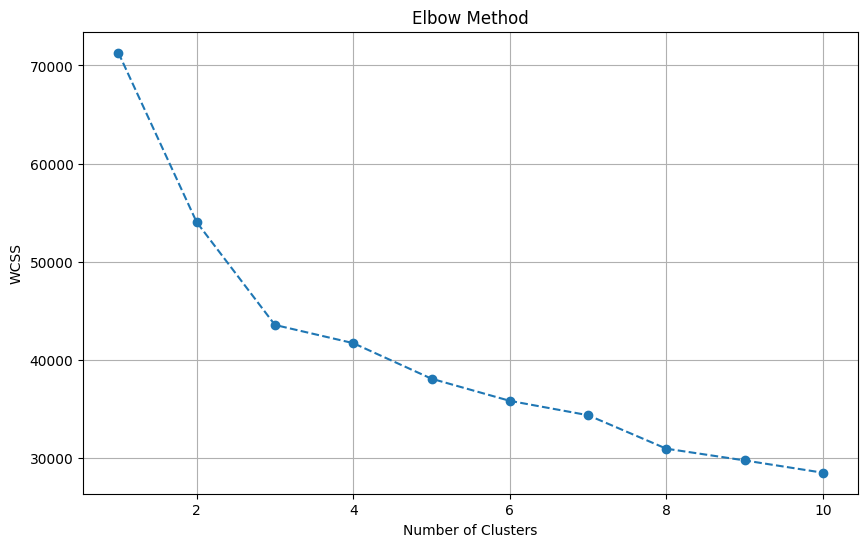

In [277]:
# plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [278]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
clusters_assignment = kmeans.fit_predict(scaled_data)

In [279]:
# 0--> Unfurnished, 1--> Semi-furnished, 2--> Furnished
df['furnishign_type'] = clusters_assignment
df[['furnishign_type']].value_counts()

furnishign_type
2                  2635
0                  1106
1                   220
Name: count, dtype: int64

In [280]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,Microwave,Curtains,Washing Machine,Exhaust Fan,Stove,TV,Modular Kitchen,Fan,Fridge,furnishign_type
2462,flat,sare crescent parc,sector 92,0.49,4909.0,998.0,Carpet area: 998 (92.72 sq.m.),2,2,2,...,0,0,0,0,0,0,0,0,0,2
2310,flat,ild grand,sector 37c,1.20,6593.0,1820.0,Super Built up area 1820(169.08 sq.m.),3,3,3,...,0,0,0,0,0,0,0,0,0,2
1909,flat,signature global the millennia 3,sector 37d,0.45,7627.0,590.0,Carpet area: 590 (54.81 sq.m.),2,3,2,...,0,0,0,0,0,0,0,0,0,2
1352,flat,bptp amstoria,sector 102,1.90,8444.0,2250.0,Super Built up area 2727(253.35 sq.m.)Built Up...,3,3,3+,...,0,0,0,0,0,0,1,5,0,2
2766,flat,parsvnath green ville,sector 48,2.00,7765.0,2576.0,Super Built up area 2125(197.42 sq.m.),3,3,0,...,0,0,0,0,0,0,0,0,0,2


## Feature Column

In [281]:
# Working with the features column to extract the features and create a scale of luxury for the properties based on the features.
df.features.isnull().sum()

np.int64(709)

In [282]:
df['society'] = df['society'].str.lower()

In [283]:
# Loading the appartment dataset
app_path = Project_root / "Data" / "Raw" / "appartments.csv"
app_df = pd.read_csv(app_path)
app_df.head()

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."
2,Adani Brahma Samsara Vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63,...","['AIPL Business Club Sector 62', 'Heritage Xpe...","{'AIPL Business Club Sector 62': '2.7 Km', 'He...",https://www.99acres.com/adani-brahma-samsara-v...,{'3 BHK': {'building_type': 'Independent Floor...,"['Terrace Garden', 'Gazebo', 'Fountain', 'Amph..."
3,Sobha City,"2, 3, 4 BHK Apartment in Sector 108, Gurgaon","['The Shikshiyan School', 'WTC Plaza', 'Luxus ...","{'The Shikshiyan School': '2.9 KM', 'WTC Plaza...",https://www.99acres.com/sobha-city-sector-108-...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Volley Ball Court', 'Aerobi..."
4,Signature Global City 93,"2, 3 BHK Independent Floor in Sector 93 Gurgaon","['Pranavananda Int. School', 'DLF Site central...","{'Pranavananda Int. School': '450 m', 'DLF Sit...",https://www.99acres.com/signature-global-city-...,{'2 BHK': {'building_type': 'Independent Floor...,"['Mini Theatre', 'Doctor on Call', 'Concierge ..."


In [284]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [285]:
temp_df = df[df['features'].isnull()]

In [286]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']


In [287]:
df['features'].isnull().sum()

np.int64(709)

In [288]:

from sklearn.preprocessing import MultiLabelBinarizer
import ast

# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: x if isinstance(x, list) else (ast.literal_eval(x) if pd.notnull(x) and str(x).startswith('[') else []))
# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [289]:

df['features'].isnull().sum()

np.int64(709)

In [290]:
features_binary_df.shape

(3961, 32)

In [291]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[[col for col in weights.keys() if col in features_binary_df.columns]].mul([weights[col] for col in weights.keys() if col in features_binary_df.columns]).sum(axis=1)

In [292]:
df['luxury_score'] = luxury_score

In [293]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,Washing Machine,Exhaust Fan,Stove,TV,Modular Kitchen,Fan,Fridge,furnishign_type,features_list,luxury_score
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,0,0,0,0,0,3,0,2,"[Feng Shui / Vaastu Compliant, Security / Fire...",28
1,flat,apna enclave,sector 5,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,...,0,1,0,0,1,4,0,0,"[Security / Fire Alarm, Maintenance Staff, Wat...",37
2,flat,tulsiani easy in homes,sector 48,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,...,0,0,0,0,0,0,0,2,"[Power Back-up, Feng Shui / Vaastu Compliant, ...",36
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,...,0,0,0,0,0,0,0,2,"[Security / Fire Alarm, Private Garden / Terra...",76
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,...,0,0,0,0,0,0,0,2,[],0


In [294]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [295]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,Curtains,Washing Machine,Exhaust Fan,Stove,TV,Modular Kitchen,Fan,Fridge,furnishign_type,luxury_score
2421,flat,mrg skyline,sector 106,1.82,13392.0,1359.0,Built Up area: 1359 (126.26 sq.m.)Carpet area:...,3,2,2,...,0,0,0,0,0,0,0,0,2,0
275,flat,unitech vistas,sector 70,0.53,4800.0,1104.0,Super Built up area 1095(101.73 sq.m.),2,2,2,...,0,0,0,0,0,0,0,0,2,24
2196,flat,smart world gems,sector 89,0.97,8794.0,1103.0,Built Up area: 1103 (102.47 sq.m.),2,2,3+,...,0,0,0,0,0,0,0,0,2,49
622,flat,bestech park view city,sector 48,1.76,9909.0,1776.0,Super Built up area 1776(165 sq.m.)Built Up ar...,3,3,3+,...,1,0,1,0,0,1,7,0,0,158
2480,flat,om appartments,sector 5,0.40,4444.0,900.0,Carpet area: 900 (83.61 sq.m.),3,2,1,...,0,0,0,0,0,0,0,0,2,7


In [296]:
df.shape

(3961, 44)

In [297]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'description', 'rating', 'Super_built_up_area',
       'Carpet_area', 'Plot_area', 'built_up_area', 'study room',
       'servant room', 'pooja room', 'store room', 'others', 'Wardrobe',
       'Dining Table', 'Water Purifier', 'Geyser', 'Bed', 'Light', 'Sofa',
       'Chimney', 'AC', 'Microwave', 'Curtains', 'Washing Machine',
       'Exhaust Fan', 'Stove', 'TV', 'Modular Kitchen', 'Fan', 'Fridge',
       'furnishign_type', 'luxury_score'],
      dtype='object')

In [298]:
df.drop(columns=['Chimney', 'Microwave', 'Washing Machine',
                 'Stove', 'TV', 'AC', 'Sofa', 'Fan', 'Fridge', 'Modular Kitchen',
                 'Wardrobe', 'Exhaust Fan', 'Light', 'Water Purifier', 'Geyser',
                 'Dining Table', 'Bed', 'Curtains'], inplace=True)

In [299]:
df.rename(columns={
    'Super_built_up_area': 'super_built_up_area',
    'Carpet_area': 'carpet_area',
    'furnishign_type': 'furnishing_type'
}, inplace=True)

print(df.shape)


(3961, 26)


In [300]:
from pathlib import Path
Project_root  = Path.cwd().parent
df.to_csv(Project_root / "Data" / "processed" / "Gurgaon_merged_v2.csv", index=False)